<a href="https://colab.research.google.com/github/SriVyshnavi-20/Tic-tac-toe/blob/main/Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Walmart_Sales.csv to Walmart_Sales.csv


Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

Load Dataset

In [5]:
df = pd.read_csv('Walmart_Sales.csv')

print(df.head())
print(df.shape)

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
(6435, 8)


Explore Data

In [6]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000

Handle Missing Values

In [7]:

print(df.isnull().sum())
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


/tmp/ipykernel_3800/871190296.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Remove Duplicates

In [8]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removal:", df.duplicated().sum())

Duplicates: 0
After removal: 0


Handle Outliers

In [11]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) &
              (df[column] <= upper)]

df = remove_outliers(df, 'Weekly_Sales')
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


Convert Date Column

In [15]:

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

print(df[['Date', 'Year', 'Month']].head())

        Date  Year     Month
0 2010-02-05  2010  February
1 2010-02-12  2010  February
2 2010-02-19  2010  February
3 2010-02-26  2010  February
4 2010-03-05  2010     March


Key Statistics Dashboard

In [16]:
print("Total Sales:", df['Weekly_Sales'].sum())

print("Average Weekly Sales:",
      df['Weekly_Sales'].mean())

print("Maximum Sales:",
      df['Weekly_Sales'].max())

print("Minimum Sales:",
      df['Weekly_Sales'].min())

Total Sales: 6632270392.99
Average Weekly Sales: 1036130.3535369473
Maximum Sales: 2685351.81
Minimum Sales: 209986.25


Monthly Sales Trend

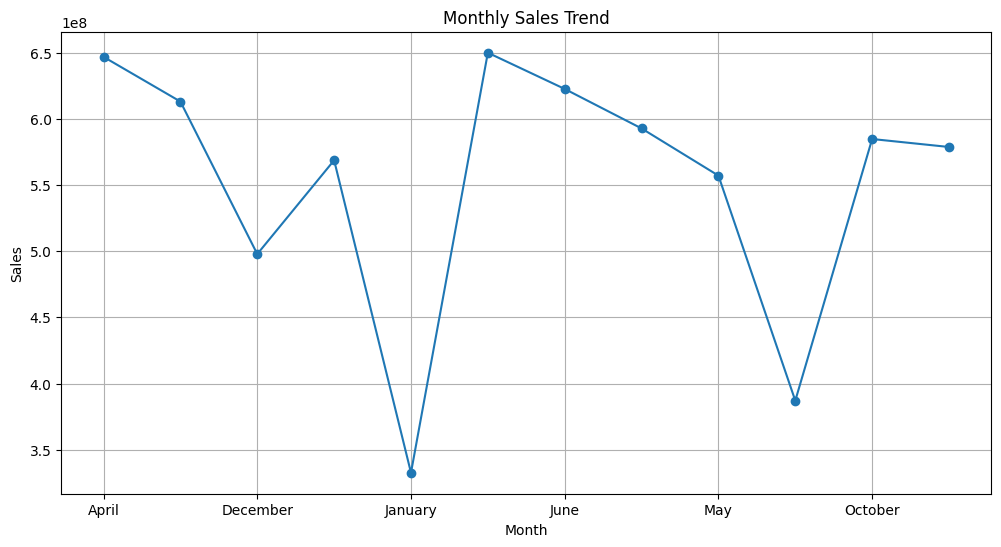

In [17]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

Store-wise Sales

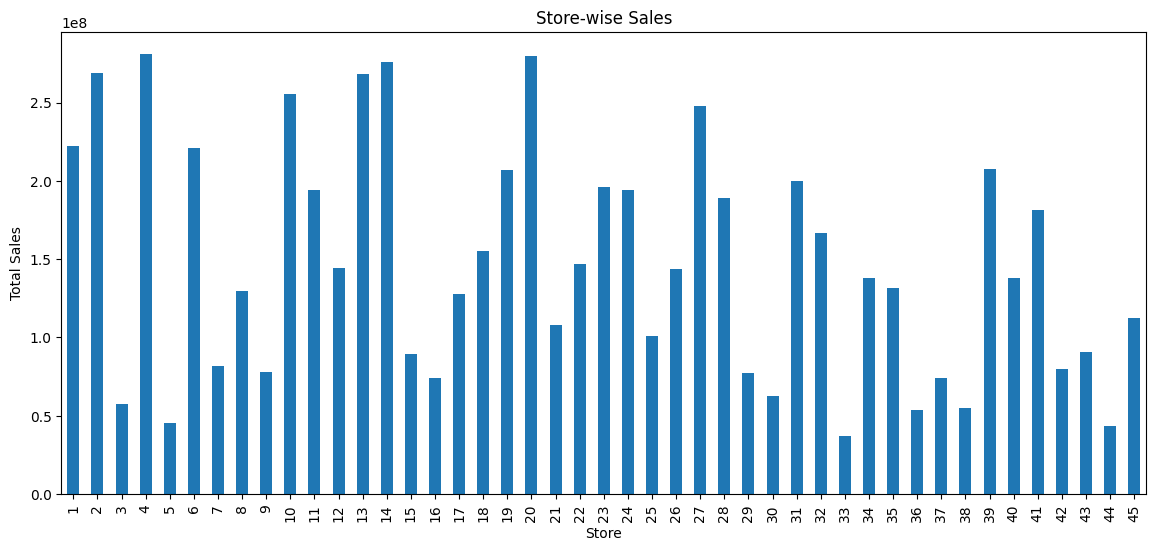

In [18]:
plt.figure(figsize=(14,6))

store_sales = df.groupby('Store')['Weekly_Sales'].sum()

store_sales.plot(kind='bar')

plt.title("Store-wise Sales")

plt.xlabel("Store")

plt.ylabel("Total Sales")

plt.show()

Holiday vs Non-Holiday Sales

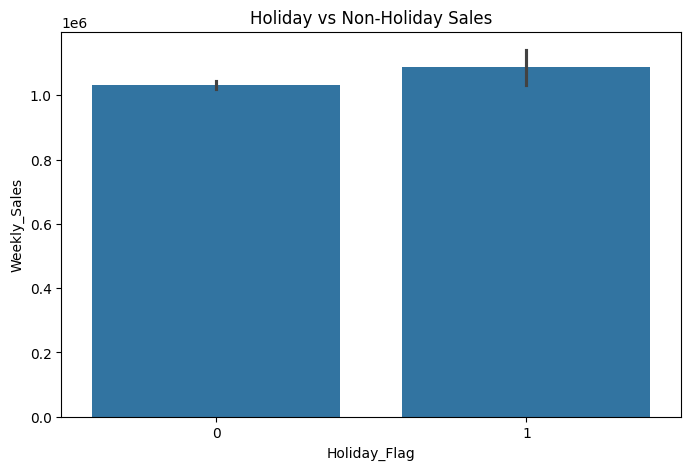

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Holiday_Flag',
    y='Weekly_Sales'
)

plt.title("Holiday vs Non-Holiday Sales")

plt.show()

Sales Distribution

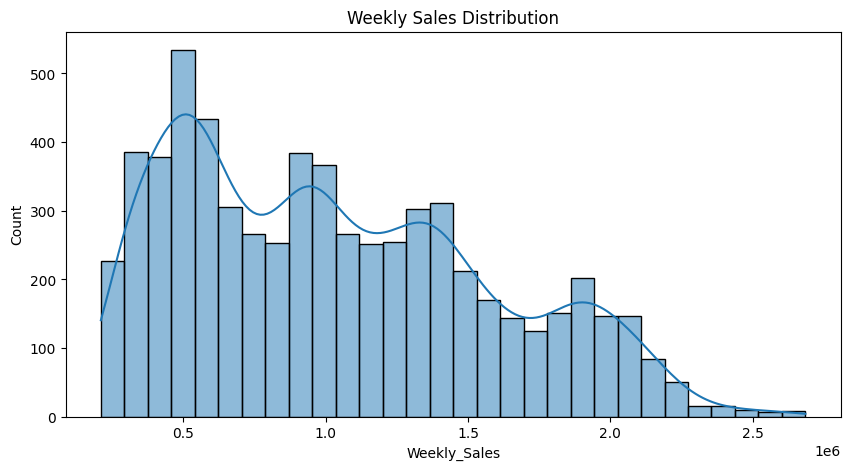

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Weekly_Sales'],
    bins=30,
    kde=True
)

plt.title("Weekly Sales Distribution")

plt.show()

Correlation Heatmap

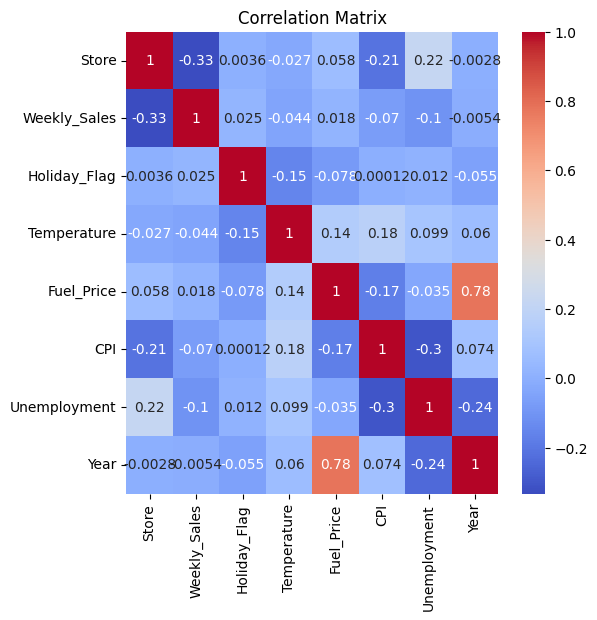

In [22]:
plt.figure(figsize=(6,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Top 10 Stores

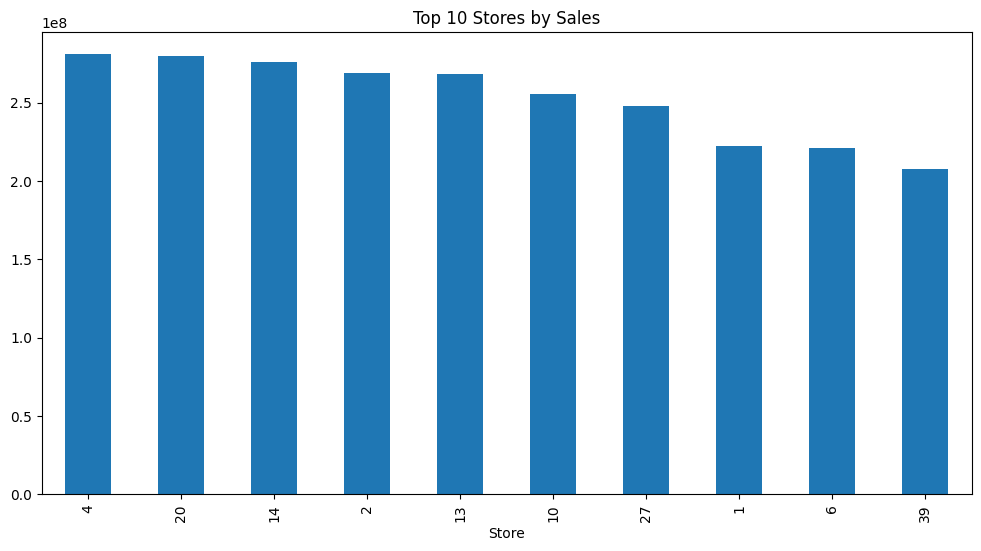

In [23]:
top_stores = (
    df.groupby('Store')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_stores.plot(kind='bar')

plt.title("Top 10 Stores by Sales")

plt.show()